In [ ]:
# prompt: connect drive

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Load the Dataset

In [ ]:
import h5py
import pandas as pd
import numpy as np
import os

# List of file paths for all the days
file_paths = [

    '/content/drive/MyDrive/MasterThesis/Aventa_Taggenberg_16_02_2022.hdf5'
]

# Define the relevant SCADA and sensor columns
scada_columns = ['WM1', 'WM2', 'WM3', 'WM4', 'WM5']  # SCADA data
sensor_columns = ['GEN_ACC_XX_01', 'GEN_ACC_YY_01', 'GEN_ACC_ZZ_01',
                  'MSB_ACC_XX_01', 'MSB_ACC_ZZ_02', 'MSH_ACC_XX_01',
                  'MSH_ACC_ZZ_01', 'NMF_ACC_XX_02', 'NMF_ACC_YY_01',
                  'NMF_ACC_YY_02']  # Sensor data

# Function to extract Time and Value from each signal
def extract_signal_data(group, signal_name):
    time_data = group[signal_name]['Time'][()]
    value_data = group[signal_name]['Value'][()]

    # Flatten the arrays if they are not 1-dimensional
    if time_data.ndim > 1:
        time_data = time_data.flatten()
    if value_data.ndim > 1:
        value_data = value_data.flatten()

    return time_data, value_data

# Initialize an empty list to store all data across files
all_files_data = []

# Loop over all files
for file_path in file_paths:
    # Extract the date (e.g., '14_02_2022') from the filename
    file_name = os.path.basename(file_path)
    day = file_name.split('_')[-3] + '_' + file_name.split('_')[-2] + '_' + file_name.split('_')[-1].split('.')[0]

    # Open the HDF5 file
    with h5py.File(file_path, 'r') as hf:
        # Navigate through the dataset (in this case 'Aventa')
        group = hf['Aventa']

        # Initialize an empty list to store all data for the current file
        all_data = []

        # Loop through each timestamp
        for timestamp in group.keys():
            timestamp_data = {}  # Dictionary to hold data for the current timestamp

            # Set a flag to track the maximum length of arrays
            max_length = 0

            # Try to extract the time from the first available signal (either SCADA or sensor)
            time_data = None
            available_signals = scada_columns + sensor_columns
            for col in available_signals:
                if col in group[timestamp]:
                    try:
                        time_data, _ = extract_signal_data(group[timestamp], col)
                        break  # Exit the loop once time is extracted from the first available signal
                    except KeyError:
                        continue

            if time_data is None:
                print(f"Unable to extract time for timestamp {timestamp} in file {file_path}")
                continue

            # Store the global time column
            timestamp_data['Time'] = time_data

            # Extract SCADA data (only the Value for each signal)
            for col in scada_columns:
                if col in group[timestamp]:
                    try:
                        _, value_data = extract_signal_data(group[timestamp], col)
                        # Update the maximum length of arrays if necessary
                        max_length = max(max_length, len(value_data))
                        timestamp_data[f'{col}_Value'] = value_data
                    except KeyError:
                        print(f"SCADA signal {col} not found in timestamp {timestamp}")
                        timestamp_data[f'{col}_Value'] = np.full_like(time_data, np.nan)

            # Extract sensor data (only the Value for each signal)
            for col in sensor_columns:
                if col in group[timestamp]:
                    try:
                        _, value_data = extract_signal_data(group[timestamp], col)
                        # Update the maximum length of arrays if necessary
                        max_length = max(max_length, len(value_data))
                        timestamp_data[f'{col}_Value'] = value_data
                    except KeyError:
                        print(f"Sensor signal {col} not found in timestamp {timestamp}")
                        timestamp_data[f'{col}_Value'] = np.full_like(time_data, np.nan)

            # Ensure all arrays are of the same length by padding with NaNs if necessary
            for key in timestamp_data:
                if len(timestamp_data[key]) < max_length:
                    timestamp_data[key] = np.pad(timestamp_data[key], (0, max_length - len(timestamp_data[key])), constant_values=np.nan)

            # Add the timestamp itself as a column (padded to match the length of other arrays)
            timestamp_data['Timestamp'] = np.array([timestamp] * max_length)

            # Add the day (derived from the filename) as a column
            timestamp_data['Day'] = np.array([day] * max_length)

            # Convert the dictionary for the current timestamp to a DataFrame and append to the list
            timestamp_df = pd.DataFrame(timestamp_data)
            all_data.append(timestamp_df)

    # Concatenate all the DataFrames for the current file
    file_df = pd.concat(all_data, ignore_index=True)

    # Add the file's data to the overall list of all files' data
    all_files_data.append(file_df)

# Concatenate all the DataFrames across all files into a single DataFrame
final_df = pd.concat(all_files_data, ignore_index=True)

# Optionally, save the final dataframe to a CSV file
#final_df.to_csv('merged_extracted_signals_data_with_day.csv', index=False)

# Show the resulting DataFrame
display(final_df.head())


,Time,WM1_Value,WM2_Value,WM3_Value,WM4_Value,WM5_Value,GEN_ACC_XX_01_Value,GEN_ACC_YY_01_Value,GEN_ACC_ZZ_01_Value,MSB_ACC_XX_01_Value,MSB_ACC_ZZ_02_Value,MSH_ACC_XX_01_Value,MSH_ACC_ZZ_01_Value,NMF_ACC_XX_02_Value,NMF_ACC_YY_01_Value,NMF_ACC_YY_02_Value,Timestamp,Day
0,0.000,61.299999,3.5,5.17,155.0,10.0,3.287354,2.340345,3.317585,3.298483,2.306518,2.293415,2.392221,2.233177,0.897722,2.280769,00_05_33,16_02_2022
1,0.005,61.599998,3.5,5.17,155.0,10.0,3.289678,2.335200,3.331679,3.300465,2.308496,2.299634,2.391392,2.234301,0.896690,2.282092,00_05_33,16_02_2022
2,0.010,0.000000,4.5,5.21,155.0,10.0,3.289163,2.270718,3.306881,3.297096,2.298027,2.304912,2.406528,2.227618,0.899515,2.283118,00_05_33,16_02_2022
3,0.015,62.299999,4.5,5.26,155.0,10.0,3.287718,2.268185,3.315650,3.299027,2.303186,2.291769,2.394574,2.237021,0.899630,2.275686,00_05_33,16_02_2022
4,0.020,62.599998,4.5,5.26,161.0,10.0,3.285265,2.258248,3.308416,3.295565,2.294953,2.292428,2.403941,2.236927,0.902660,2.270339,00_05_33,16_02_2022


In [ ]:
print(final_df.shape)


(17278159, 18)


In [ ]:
import pandas as pd
from datetime import datetime, timedelta

# Assuming 'Day' is in 'dd_mm_yyyy' format and 'Time' is in seconds
def create_datetime_column(df):
    # Convert the 'Day' column to a datetime object (assumed format is 'dd_mm_yyyy')
    df['Day'] = pd.to_datetime(df['Day'], format='%d_%m_%Y')

    # Create the 'Date' column by combining 'Day' with 'Time'
    df['Date'] = df.apply(lambda row: row['Day'] + timedelta(seconds=row['Time']), axis=1)

    return df

# Example usage:
final_df_with_date = create_datetime_column(final_df)

In [ ]:
final_df_with_date.head()

,Time,WM1_Value,WM2_Value,WM3_Value,WM4_Value,WM5_Value,GEN_ACC_XX_01_Value,GEN_ACC_YY_01_Value,GEN_ACC_ZZ_01_Value,MSB_ACC_XX_01_Value,MSB_ACC_ZZ_02_Value,MSH_ACC_XX_01_Value,MSH_ACC_ZZ_01_Value,NMF_ACC_XX_02_Value,NMF_ACC_YY_01_Value,NMF_ACC_YY_02_Value,Timestamp,Day,Date
0,0.000,61.299999,3.5,5.17,155.0,10.0,3.287354,2.340345,3.317585,3.298483,2.306518,2.293415,2.392221,2.233177,0.897722,2.280769,00_05_33,2022-02-16,2022-02-16 00:00:00.000
1,0.005,61.599998,3.5,5.17,155.0,10.0,3.289678,2.335200,3.331679,3.300465,2.308496,2.299634,2.391392,2.234301,0.896690,2.282092,00_05_33,2022-02-16,2022-02-16 00:00:00.005
2,0.010,0.000000,4.5,5.21,155.0,10.0,3.289163,2.270718,3.306881,3.297096,2.298027,2.304912,2.406528,2.227618,0.899515,2.283118,00_05_33,2022-02-16,2022-02-16 00:00:00.010
3,0.015,62.299999,4.5,5.26,155.0,10.0,3.287718,2.268185,3.315650,3.299027,2.303186,2.291769,2.394574,2.237021,0.899630,2.275686,00_05_33,2022-02-16,2022-02-16 00:00:00.015
4,0.020,62.599998,4.5,5.26,161.0,10.0,3.285265,2.258248,3.308416,3.295565,2.294953,2.292428,2.403941,2.236927,0.902660,2.270339,00_05_33,2022-02-16,2022-02-16 00:00:00.020


In [ ]:
final_df_with_date.shape

(17278159, 19)

In [ ]:
final_df_with_date['Date'] = pd.to_datetime(final_df_with_date['Date'])

#only show dates in day 16
#final_df_with_date = final_df_with_date[final_df_with_date['Date'].dt.day == 16]

#make it time 03:15 in the morning
final_df_with_date_specific = final_df_with_date[(final_df_with_date['Date'].dt.hour == 3) & (final_df_with_date['Date'].dt.minute == 15)]


In [ ]:
final_df_with_date.dtypes

,0
Time,float32
WM1_Value,float32
WM2_Value,float32
WM3_Value,float32
WM4_Value,float32
WM5_Value,float32
GEN_ACC_XX_01_Value,float32
GEN_ACC_YY_01_Value,float32
GEN_ACC_ZZ_01_Value,float32
MSB_ACC_XX_01_Value,float32


In [ ]:
final_df_with_date.shape

(17278159, 19)

In [ ]:
final_df_with_date['Timestamp'].unique()

array(['00_05_33', '00_15_34', '00_25_35', '00_35_36', '00_45_37',
       '00_55_38', '01_05_39', '01_15_40', '01_25_41', '01_35_42',
       '01_45_43', '01_55_44', '02_05_45', '02_15_46', '02_25_47',
       '02_35_48', '02_45_49', '02_55_50', '03_05_51', '03_15_52',
       '03_25_53', '03_35_54', '03_45_55', '03_55_56', '04_05_57',
       '04_15_58', '04_25_59', '04_36_00', '04_46_01', '04_56_02',
       '05_06_03', '05_16_04', '05_26_05', '05_36_06', '05_46_07',
       '05_56_08', '06_06_09', '06_16_10', '06_26_11', '06_36_12',
       '06_46_13', '06_56_14', '07_06_15', '07_16_16', '07_26_17',
       '07_36_18', '07_46_19', '07_56_20', '08_06_21', '08_16_22',
       '08_26_23', '08_36_24', '08_46_25', '08_56_26', '09_06_27',
       '09_16_28', '09_26_29', '09_36_30', '09_46_31', '09_56_32',
       '10_06_33', '10_16_34', '10_26_35', '10_36_36', '10_46_37',
       '10_56_38', '11_06_39', '11_16_40', '11_26_41', '11_36_42',
       '11_46_43', '11_56_44', '12_06_45', '12_16_46', '12_26_

In [ ]:
test = final_df_with_date[final_df_with_date['Timestamp'].isin(["17_32_34"])]

In [ ]:
test

,Time,WM1_Value,WM2_Value,WM3_Value,WM4_Value,WM5_Value,GEN_ACC_XX_01_Value,GEN_ACC_YY_01_Value,GEN_ACC_ZZ_01_Value,MSB_ACC_XX_01_Value,MSB_ACC_ZZ_02_Value,MSH_ACC_XX_01_Value,MSH_ACC_ZZ_01_Value,NMF_ACC_XX_02_Value,NMF_ACC_YY_01_Value,NMF_ACC_YY_02_Value,Timestamp,Day,Date
12589110,0.000000,9.9,8.7,0.0,188.0,13.0,3.286500,2.279314,3.314635,3.296639,2.297382,2.289924,2.399953,2.237399,0.904079,2.265033,17_32_34,2022-02-16,2022-02-16 00:00:00.000000
12589111,0.005000,0.0,8.7,0.0,188.0,13.0,3.286717,2.278871,3.316515,3.296884,2.297800,2.291495,2.400814,2.237514,0.904258,2.266020,17_32_34,2022-02-16,2022-02-16 00:00:00.005000
12589112,0.010000,10.0,8.7,0.0,188.0,13.0,3.287009,2.280521,3.316476,3.297129,2.298834,2.292471,2.400723,2.238188,0.904581,2.266398,17_32_34,2022-02-16,2022-02-16 00:00:00.010000
12589113,0.015000,10.1,8.7,0.0,194.0,13.0,3.286627,2.280568,3.314177,3.296866,2.298463,2.291315,2.399722,2.237713,0.904485,2.265231,17_32_34,2022-02-16,2022-02-16 00:00:00.015000
12589114,0.020000,10.1,8.7,0.0,190.0,13.0,3.286245,2.279080,3.314162,3.296639,2.297400,2.290936,2.399812,2.237306,0.904403,2.264013,17_32_34,2022-02-16,2022-02-16 00:00:00.020000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12709343,601.165039,NaN,NaN,NaN,NaN,NaN,3.285769,2.282048,3.313957,3.297175,2.305409,2.297709,2.392823,2.230251,0.902770,2.269626,17_32_34,2022-02-16,2022-02-16 00:10:01.165039
12709344,601.170044,NaN,NaN,NaN,NaN,NaN,3.286486,2.283702,3.317174,3.297431,2.306010,2.298272,2.393583,2.230882,0.903063,2.270692,17_32_34,2022-02-16,2022-02-16 00:10:01.170044
12709345,601.175049,NaN,NaN,NaN,NaN,NaN,3.286818,2.284869,3.316335,3.297320,2.306245,2.298520,2.394505,2.231044,0.903396,2.271874,17_32_34,2022-02-16,2022-02-16 00:10:01.175049
12709346,601.180054,NaN,NaN,NaN,NaN,NaN,3.286259,2.283471,3.313392,3.296967,2.305146,2.297414,2.394246,2.230662,0.903028,2.270898,17_32_34,2022-02-16,2022-02-16 00:10:01.180054


In [ ]:
# Group by 'Time_seconds' and compute the mean for each second
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams['agg.path.chunksize'] = 10000


# Define the columns to plot
columns_to_plot = features = [
            'GEN_ACC_XX_01_Value', 'GEN_ACC_YY_01_Value', 'GEN_ACC_ZZ_01_Value',
            'MSB_ACC_XX_01_Value', 'MSB_ACC_ZZ_02_Value', 'MSH_ACC_XX_01_Value',
            'MSH_ACC_ZZ_01_Value', 'NMF_ACC_XX_02_Value', 'NMF_ACC_YY_01_Value', 'NMF_ACC_YY_02_Value']

# Plot the grouped time series for the selected columns
for column in columns_to_plot:
    plt.figure(figsize=(15, 10))
    plt.plot(test['Time'], test[column], label=column)
    plt.title(f'Time Series Plot: {column} (Grouped by Seconds)')
    plt.xlabel('Time (seconds)')
    plt.ylabel(column)
plt.tight_layout()

plt.show()


In [ ]:
#plot these columns but make sure to remove null values

columns_to_plot = ['WM1_Value', 'WM2_Value', 'WM3_Value', 'WM4_Value', 'WM5_Value']

# Plot the grouped time series for the selected columns
for column in columns_to_plot:
    plt.figure(figsize=(15, 10))
    plt.plot(test['Time'], test[column], label=column)
    plt.title(f'Time Series Plot: {column} (Grouped by Seconds)')
    plt.xlabel('Time (seconds)')
    plt.ylabel(column)
plt.tight_layout()

plt.show()


# Point detection using PELT Algorith to detect the change in point at the time of failure

Overview
The code is designed to:

 - Extract and process a given timestamp's data from a DataFrame.
- Label the data based on whether a fault occurred within a specified time window.
- Downsample and smooth the data for easier analysis.
- Detect significant changes (change points) using the ruptures package.
- Calculate the magnitude of these changes and identify significant ones.
- Plot the change points and data with visual markers for significant changes.
- Return the detected change points and distribution of fault labels (if fault data exists)

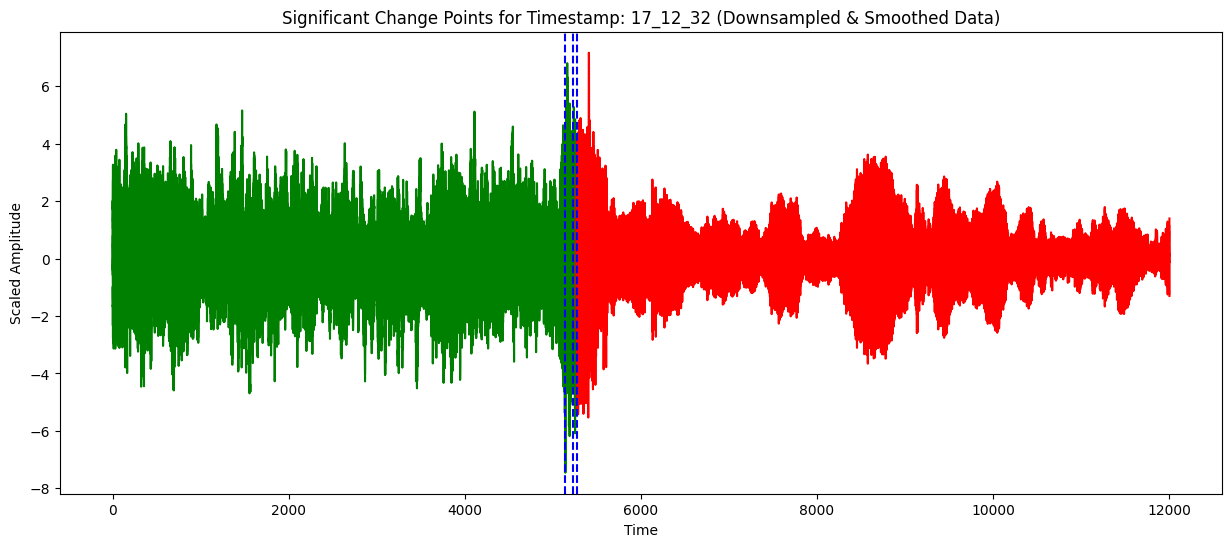

In [ ]:
import pandas as pd
import numpy as np
import ruptures as rpt
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Step 1: Extract the full timestamp with already labeled data
timestamp = "17_12_32"
features = [
    'GEN_ACC_XX_01_Value', 'GEN_ACC_YY_01_Value', 'GEN_ACC_ZZ_01_Value',
    'MSB_ACC_XX_01_Value', 'MSB_ACC_ZZ_02_Value', 'MSH_ACC_XX_01_Value',
    'MSH_ACC_ZZ_01_Value', 'NMF_ACC_XX_02_Value', 'NMF_ACC_YY_01_Value', 'NMF_ACC_YY_02_Value'
]

# Extract the full timestamp (600 seconds)
original_timestamp_df = final_df_with_date[final_df_with_date['Timestamp'] == timestamp].copy()

# Step 2: Label the data as normal (0) initially, then assign fault labels (1) between 250 and 300 seconds
fault_start_seconds = 250
fault_end_seconds = 300

original_timestamp_df['Label'] = 0  # Initialize all data as normal (label 0)
original_timestamp_df.loc[
    (original_timestamp_df['Time'] >= fault_start_seconds) &
    (original_timestamp_df['Time'] <= fault_end_seconds), 'Label'
] = 1

# Step 3: Downsample the data (e.g., keep every 10th data point to reduce size)
downsampled_df = original_timestamp_df.iloc[::10, :].copy()  # Keep every 10th point

# Step 4: Apply rolling mean (smoothing) to reduce noise
smoothed_df = downsampled_df[features].rolling(window=20, center=True).mean()  # 5-point rolling average

# Step 5: Standardize the data (scale all features to have zero mean and unit variance)
scaler = StandardScaler()
X_downsampled_scaled = scaler.fit_transform(smoothed_df.dropna())  # Drop NaN caused by rolling window

# Step 6: Use ruptures to detect change points with a higher penalty value
algo = rpt.Pelt(model="l2").fit(X_downsampled_scaled)  # Use the 'l2' model... to detect change in the mean at the time of failure
change_points = algo.predict(pen=300)  # Increased penalty to reduce over-detection

# Step 7: Calculate the magnitude of change at each change point
def calculate_change_magnitude(data, change_points):
    magnitudes = []
    for i in range(len(change_points) - 1):
        start, end = change_points[i], change_points[i+1]
        before = data[start:start+10].mean(axis=0)  # Mean of 10 points before
        after = data[end-10:end].mean(axis=0)  # Mean of 10 points after
        magnitude = np.linalg.norm(after - before)  # Euclidean distance
        magnitudes.append((start, end, magnitude))
    return magnitudes

change_magnitudes = calculate_change_magnitude(X_downsampled_scaled, change_points)

# Step 8: Apply threshold to filter out small change points
threshold = np.percentile([m[2] for m in change_magnitudes], 90)  # Use 75th percentile as threshold
significant_changes = [cm for cm in change_magnitudes if cm[2] > threshold]

# Step 9: Extract significant change points
significant_change_points = [0] + [sc[1] for sc in significant_changes] + [len(X_downsampled_scaled)]

# Step 10: Plot the detected significant change points
# Modify the plotting section (Step 10 in the previous code)
plt.figure(figsize=(15, 6))

# Custom color function
def get_color(index):
    if index < significant_change_points[-2]:  # Normal operation
        return 'green'
    else:  # Fault condition
        return 'red'

# Plot each segment with appropriate color
for start, end in zip(significant_change_points[:-1], significant_change_points[1:]):
    plt.plot(range(start, end), X_downsampled_scaled[start:end], color=get_color(start))

# Add vertical lines for change points
for chg_pt in significant_change_points[1:-1]:
    plt.axvline(x=chg_pt, color='blue', linestyle='--')

plt.title(f"Significant Change Points for Timestamp: {timestamp} (Downsampled & Smoothed Data)")
plt.xlabel("Time")
plt.ylabel("Scaled Amplitude")
plt.show()

#### **Fault Detection Model Using Rolling Variance and Statistical Comparison**

Key Steps of the Model
1. Data Preparation
The model starts by extracting time series data for a specified timestamp and calculating the mean signal of several selected features.
The mean signal is normalized (mean = 0, variance = 1) to standardize the scale of the data, ensuring that all features contribute equally to the analysis.
2. Rolling Variance Calculation
The model calculates the rolling variance over a moving window (default window size = 100). Rolling variance captures fluctuations in the data, with higher variance indicating periods of instability or unusual behavior.
The rolling variance is used to detect peaks (i.e., moments of high volatility) that might indicate the onset of a fault.
3. Peak and Fault Detection
The model detects a peak in the rolling variance, representing a moment of high volatility in the time series.
It then looks for a significant drop in variance within a predefined time window (between min_fault_time and max_fault_time, typically 10 to 20 seconds after the peak). The drop must be by a factor defined by threshold_factor (default is 5), meaning the variance needs to fall to less than 20% of its peak value.
4. Statistical Comparison
Once a potential fault (variance drop) is detected, the model performs a statistical comparison using a t-test to verify whether the system behavior before the peak and after the fault is significantly different:
Pre-peak window: The model examines the signal 60 seconds before the peak.
Post-fault window: It examines the signal for 10 seconds after the fault.
The model checks the mean and standard deviation of the signal in these two windows and tests whether they are statistically different using a t-test.
The fault is confirmed if:
The means and standard deviations differ by more than a threshold (default is 50% difference), and
The t-test returns a high p-value (p > 0.05), indicating the differences are statistically significant.
If the signal is not significantly different before and after the fault, the model discards the fault as a false positive.

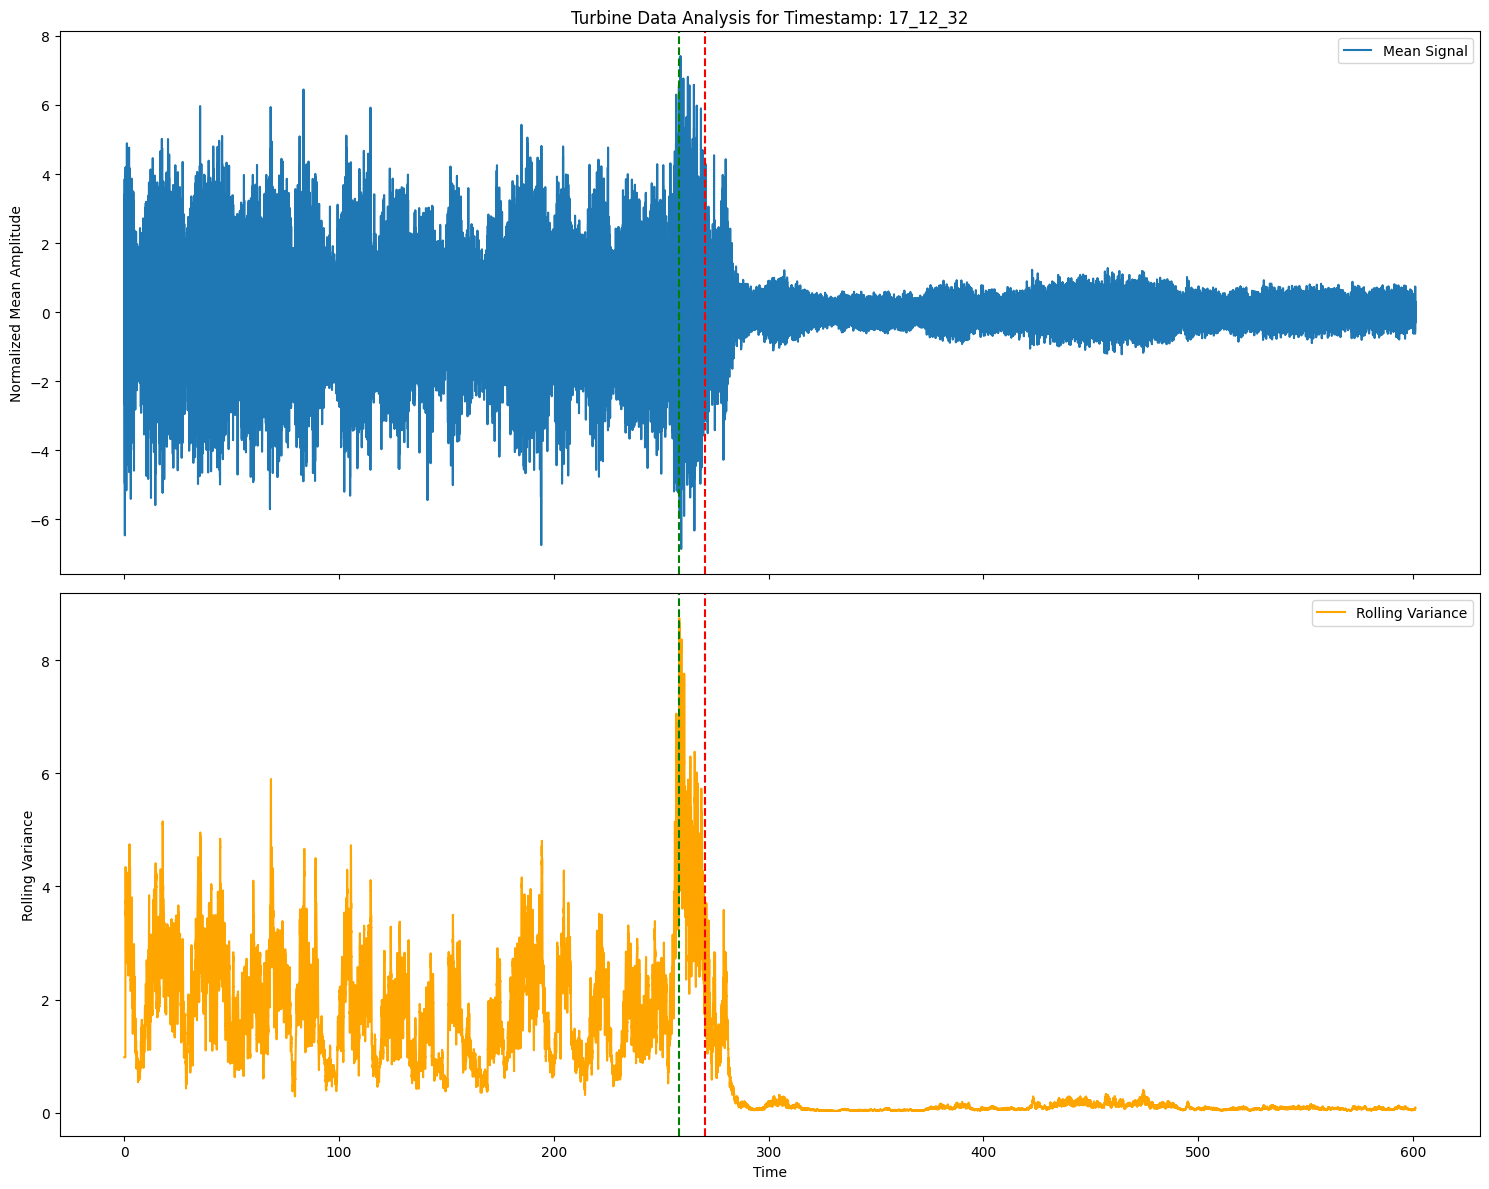

Timestamp: 17_12_32
  Peak detected at time: 258.41 seconds
  Fault detected at time: 270.47 seconds
  Time between peak and fault: 12.06 seconds
  Fault confirmed: Statistics before peak and after fault are different
---


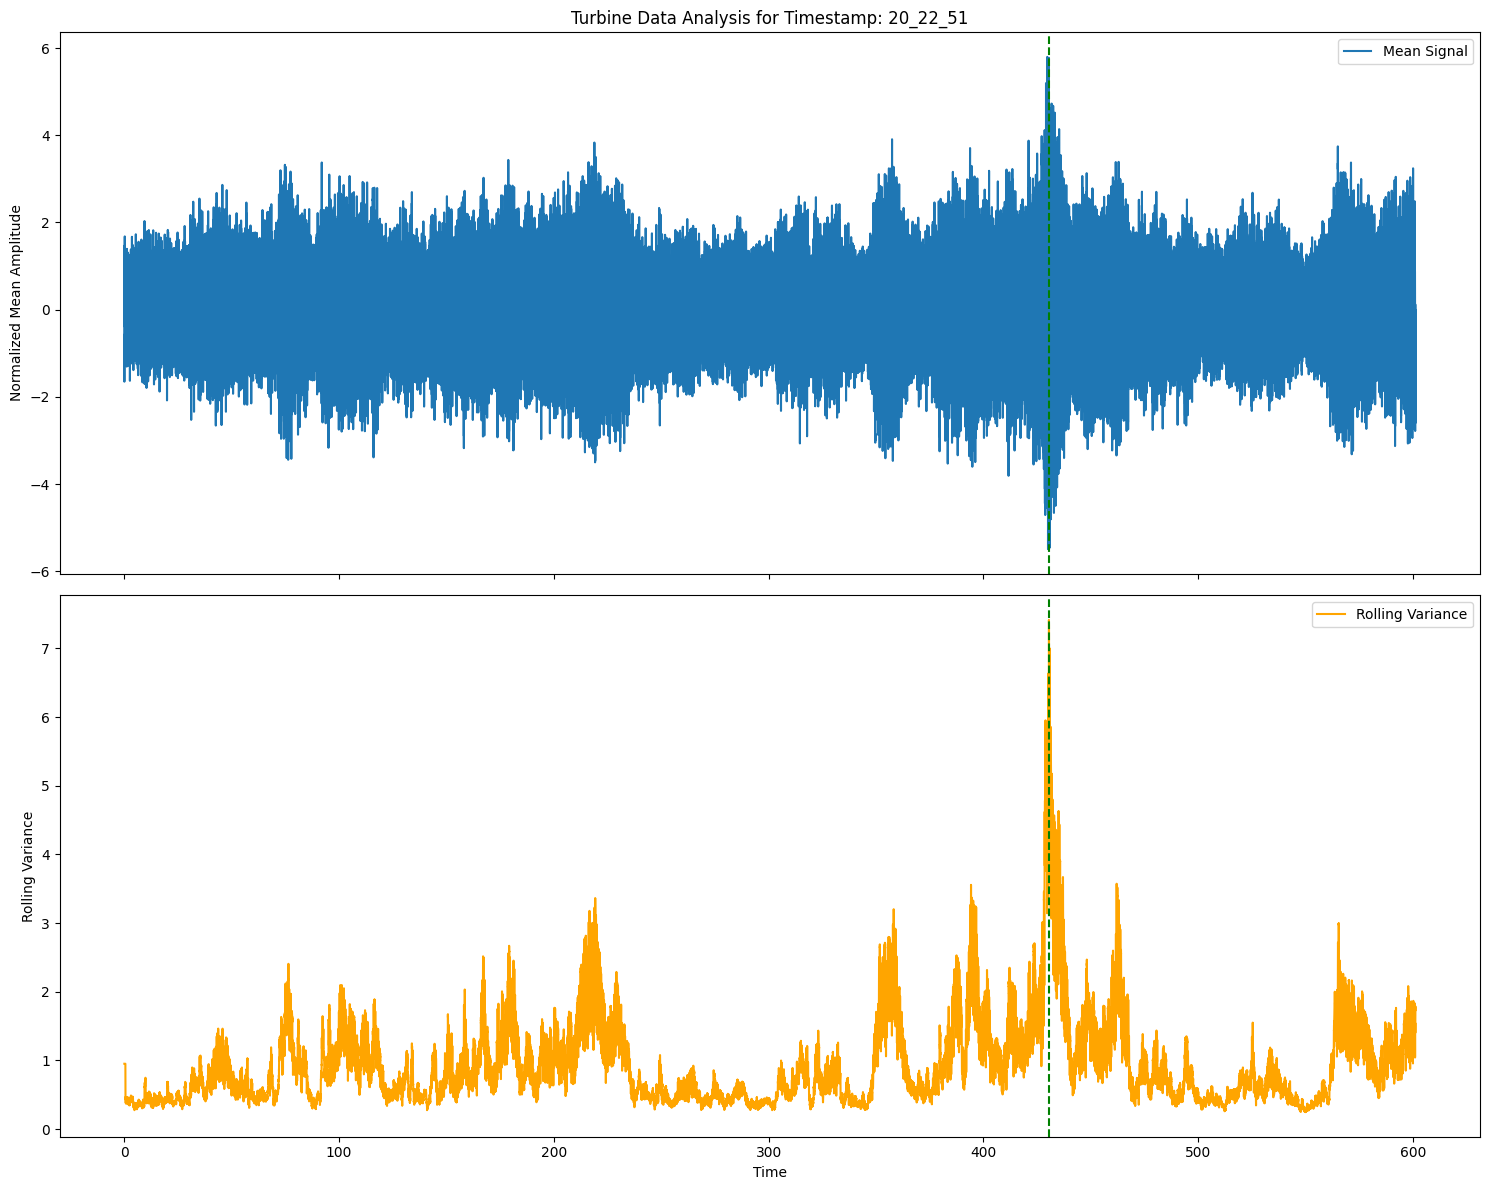

Timestamp: 20_22_51
  Peak detected at time: 430.52 seconds
  No fault detected: Either no significant drop in variance or statistics are similar
---
Overall Statistics:
Total timestamps analyzed: 2
Total faults detected: 1
Percentage of timestamps with faults: 50.00%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def compare_statistics(signal, time_values, peak_index, fault_index):
    # 60 seconds before peak
    pre_peak_start = np.searchsorted(time_values, time_values[peak_index] - 60)
    pre_peak_window = signal[pre_peak_start:peak_index]

    # 10 seconds after fault
    post_fault_end = np.searchsorted(time_values, time_values[fault_index] + 10)
    post_fault_window = signal[fault_index:post_fault_end]

    pre_mean, pre_std = np.mean(pre_peak_window), np.std(pre_peak_window)
    post_mean, post_std = np.mean(post_fault_window), np.std(post_fault_window)

    # Check if means are significantly different
    t_stat, p_value = stats.ttest_ind(pre_peak_window, post_fault_window)

    # Define thresholds for similarity
    mean_threshold = 0.5  # 20% difference in means
    std_threshold = 0.5   # 20% difference in standard deviations

    means_similar = abs(pre_mean - post_mean) / max(abs(pre_mean), abs(post_mean)) < mean_threshold
    stds_similar = abs(pre_std - post_std) / max(pre_std, post_std) < std_threshold

    return means_similar and stds_similar and p_value > 0.05

def detect_fault(rolling_variance, time_values, mean_signal, threshold_factor=5, min_fault_time=10, max_fault_time=20):
    if len(rolling_variance) == 0 or np.all(np.isnan(rolling_variance)):
        return None, None

    peak_index = np.nanargmax(rolling_variance)
    peak_value = rolling_variance[peak_index]
    peak_time = time_values[peak_index]

    for i in range(peak_index + 1, len(rolling_variance)):
        current_time = time_values[i]
        time_since_peak = current_time - peak_time

        if min_fault_time <= time_since_peak <= max_fault_time:
            if rolling_variance[i] < peak_value / threshold_factor:
                if compare_statistics(mean_signal, time_values, peak_index, i):
                    return peak_index, None  # Not a fault if statistics are similar
                return peak_index, i
        elif time_since_peak > max_fault_time:
            break

    return peak_index, None

def analyze_timestamp(df, timestamp, feature_columns, window_size=100):
    timestamp_df = df[df['Timestamp'] == timestamp].copy()

    existing_features = [col for col in feature_columns if col in timestamp_df.columns]
    if len(existing_features) != len(feature_columns):
        print(f"Warning: Some features are missing for timestamp {timestamp}")

    if len(existing_features) == 0 or len(timestamp_df) == 0:
        print(f"Error: No valid data for timestamp {timestamp}")
        return None, None, None, None, None

    mean_signal = timestamp_df[existing_features].mean(axis=1).values
    time_values = timestamp_df['Time'].values

    mean_signal = (mean_signal - np.mean(mean_signal)) / np.std(mean_signal)

    rolling_variance = pd.Series(mean_signal).rolling(window=window_size).var().values
    rolling_variance = np.nan_to_num(rolling_variance, nan=np.nanmean(rolling_variance))

    peak_index, fault_index = detect_fault(rolling_variance, time_values, mean_signal)

    return mean_signal, time_values, rolling_variance, peak_index, fault_index

# List of timestamps to analyze
timestamps_to_analyze = ["17_12_32", "20_22_51"]  # Add more timestamps as needed

# List of feature columns
feature_columns = [
    'GEN_ACC_XX_01_Value', 'GEN_ACC_YY_01_Value', 'GEN_ACC_ZZ_01_Value',
    'MSB_ACC_XX_01_Value', 'MSB_ACC_ZZ_02_Value', 'MSH_ACC_XX_01_Value',
    'MSH_ACC_ZZ_01_Value', 'NMF_ACC_XX_02_Value', 'NMF_ACC_YY_01_Value', 'NMF_ACC_YY_02_Value'
]

for timestamp in timestamps_to_analyze:
    result = analyze_timestamp(final_df_with_date, timestamp, feature_columns)

    if result[0] is None:
        print(f"Timestamp: {timestamp}")
        print("  No valid data or faults detected")
        print("---")
        continue

    mean_signal, time_values, rolling_variance, peak_index, fault_index = result

    # Plotting
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

    # Plot mean signal
    ax1.plot(time_values, mean_signal, label='Mean Signal')
    ax1.set_title(f"Turbine Data Analysis for Timestamp: {timestamp}")
    ax1.set_ylabel("Normalized Mean Amplitude")
    ax1.legend()

    # Plot rolling variance
    ax2.plot(time_values, rolling_variance, label='Rolling Variance', color='orange')
    ax2.set_ylabel("Rolling Variance")
    ax2.set_xlabel("Time")
    ax2.legend()

    # Mark peak and fault points
    if peak_index is not None:
        ax1.axvline(x=time_values[peak_index], color='green', linestyle='--', label='Peak')
        ax2.axvline(x=time_values[peak_index], color='green', linestyle='--')
        if fault_index is not None:
            ax1.axvline(x=time_values[fault_index], color='red', linestyle='--', label='Fault')
            ax2.axvline(x=time_values[fault_index], color='red', linestyle='--')

    plt.tight_layout()
    plt.show()

    # Print statistics
    print(f"Timestamp: {timestamp}")
    if peak_index is not None:
        print(f"  Peak detected at time: {time_values[peak_index]:.2f} seconds")
        if fault_index is not None:
            time_to_fault = time_values[fault_index] - time_values[peak_index]
            print(f"  Fault detected at time: {time_values[fault_index]:.2f} seconds")
            print(f"  Time between peak and fault: {time_to_fault:.2f} seconds")
            print("  Fault confirmed: Statistics before peak and after fault are different")
        else:
            print("  No fault detected: Either no significant drop in variance or statistics are similar")
    else:
        print("  No peak detected")
    print("---")

# Calculate overall statistics
total_faults = sum(1 for ts in timestamps_to_analyze if analyze_timestamp(final_df_with_date, ts, feature_columns)[4] is not None)

print("Overall Statistics:")
print(f"Total timestamps analyzed: {len(timestamps_to_analyze)}")
print(f"Total faults detected: {total_faults}")
print(f"Percentage of timestamps with faults: {total_faults / len(timestamps_to_analyze) * 100:.2f}%")

# **Anomaly detection using Isolation Forest**

Model training complete.
Total anomalies detected in training data: 1106


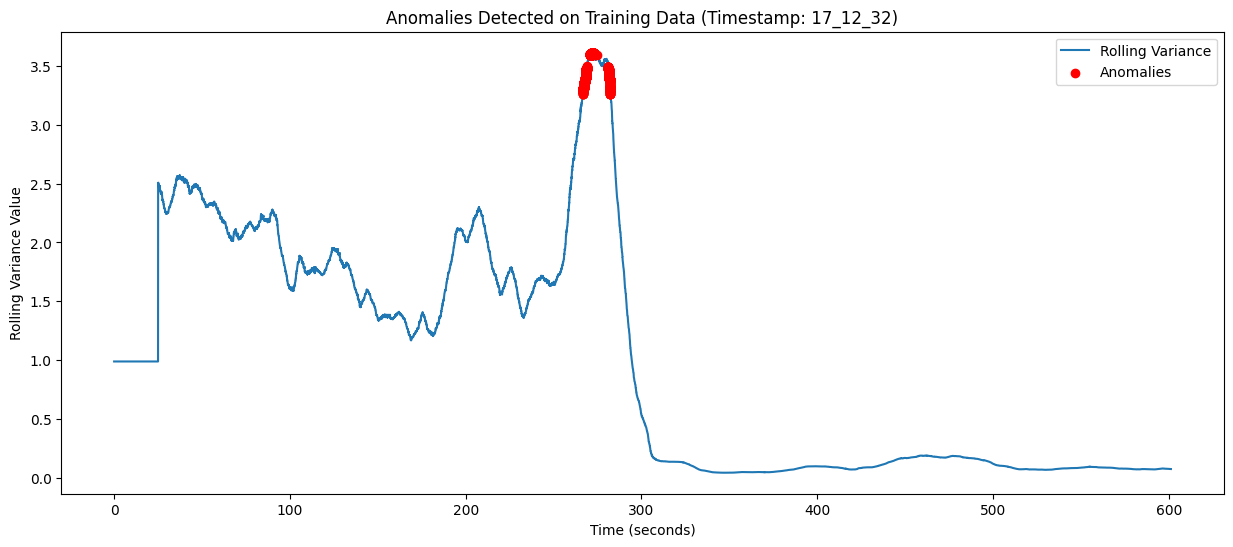

Total anomalies detected in test data: 1539


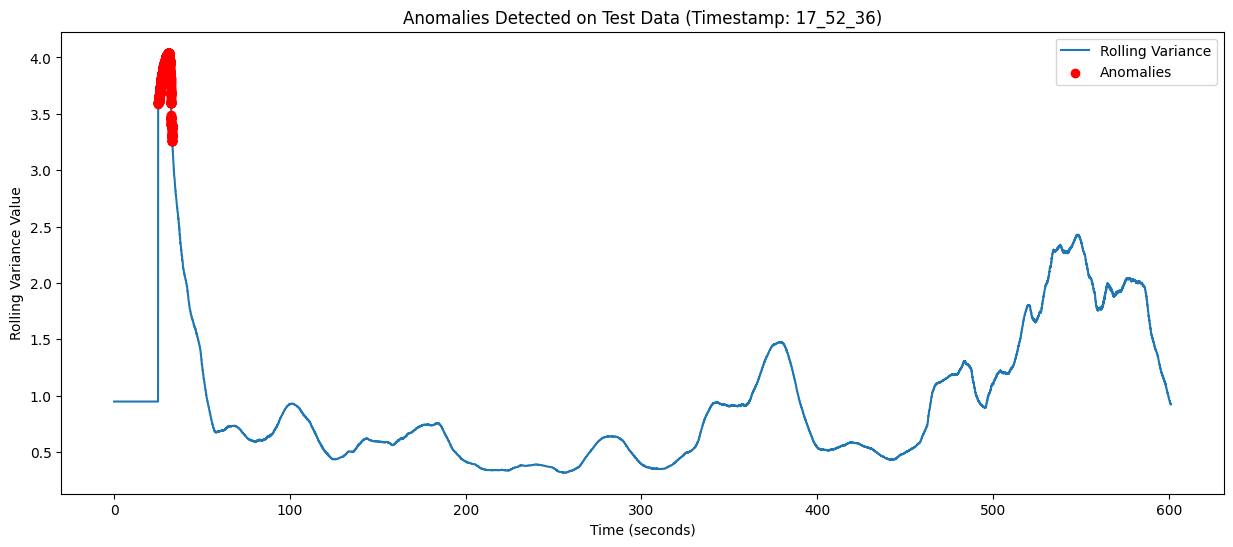

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Step 1: Prepare the data with rolling variance based on the mean signal
def prepare_data_with_rolling_variance(df, timestamp, feature_columns, window_size):
    # Extract the data for the given timestamp
    timestamp_df = df[df['Timestamp'] == timestamp].copy()

    # Ensure we are using only valid features present in the dataframe
    existing_features = [col for col in feature_columns if col in timestamp_df.columns]
    if len(existing_features) == 0:
        print(f"Error: No valid data for timestamp {timestamp}")
        return None, None

    # Calculate the mean signal across the features
    mean_signal = timestamp_df[existing_features].mean(axis=1).values

    # Normalize the mean signal
    mean_signal = (mean_signal - np.mean(mean_signal)) / np.std(mean_signal)

    # Calculate rolling variance over the mean signal
    rolling_variance = pd.Series(mean_signal).rolling(window=window_size).var().values

    # Handle NaNs in rolling variance (replace with the mean variance)
    rolling_variance = np.nan_to_num(rolling_variance, nan=np.nanmean(rolling_variance))

    # Return the rolling variance and corresponding time values
    time_values = timestamp_df['Time'].values
    return rolling_variance, time_values

# Step 2: Plot the rolling variance with detected anomalies
def plot_anomalies(time_values, rolling_variance, anomalies, title):
    plt.figure(figsize=(15, 6))

    # Plot the rolling variance over time
    plt.plot(time_values, rolling_variance, label="Rolling Variance")

    # Highlight the detected anomalies
    plt.scatter(time_values[anomalies], rolling_variance[anomalies], color='red', label='Anomalies', zorder=5)

    plt.title(title)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Rolling Variance Value")
    plt.legend()
    plt.show()

# List of feature columns (sensor values)
feature_columns = [
    'GEN_ACC_XX_01_Value', 'GEN_ACC_YY_01_Value', 'GEN_ACC_ZZ_01_Value',
    'MSB_ACC_XX_01_Value', 'MSB_ACC_ZZ_02_Value', 'MSH_ACC_XX_01_Value',
    'MSH_ACC_ZZ_01_Value', 'NMF_ACC_XX_02_Value', 'NMF_ACC_YY_01_Value', 'NMF_ACC_YY_02_Value'
]

# Training timestamp
train_timestamp = "17_12_32"
window_size = 5000  # Set the window size for rolling variance

# Step 3: Train the model on the rolling variance of the training timestamp
rolling_variance_train, time_values_train = prepare_data_with_rolling_variance(final_df_with_date, train_timestamp, feature_columns, window_size)

if rolling_variance_train is not None:
    # Normalize the rolling variance data
    scaler = StandardScaler()
    rolling_variance_train_scaled = scaler.fit_transform(rolling_variance_train.reshape(-1, 1))

    # Train an Isolation Forest model on the rolling variance data
    iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
    iso_forest.fit(rolling_variance_train_scaled)  # Train the model

    print("Model training complete.")

    # Step 4: Plot the anomalies on the training data
    y_pred_train = iso_forest.predict(rolling_variance_train_scaled)

    # Anomalies are labeled as -1, normal points as 1
    anomalies_train = np.where(y_pred_train == -1)[0]

    # DEBUG: Check how many anomalies were detected
    print(f"Total anomalies detected in training data: {len(anomalies_train)}")

    # Plot the anomalies on the rolling variance of the training time series
    plot_anomalies(time_values_train, rolling_variance_train, anomalies_train, title="Anomalies Detected on Training Data (Timestamp: 17_12_32)")

    # Now we test on a new timestamp
    test_timestamp = "17_52_36"
    rolling_variance_test, time_values_test = prepare_data_with_rolling_variance(final_df_with_date, test_timestamp, feature_columns, window_size)

    if rolling_variance_test is not None:
        # Normalize the test data using the same scaler as training
        rolling_variance_test_scaled = scaler.transform(rolling_variance_test.reshape(-1, 1))

        # Predict anomalies on the new timestamp
        y_pred_test = iso_forest.predict(rolling_variance_test_scaled)

        # Anomalies are labeled as -1, normal points as 1
        anomalies_test = np.where(y_pred_test == -1)[0]

        # DEBUG: Check how many anomalies were detected
        print(f"Total anomalies detected in test data: {len(anomalies_test)}")

        # Plot the anomalies on the rolling variance of the test time series
        plot_anomalies(time_values_test, rolling_variance_test, anomalies_test, title="Anomalies Detected on Test Data (Timestamp: 17_52_36)")
    else:
        print("No valid data to test on.")
else:
    print("No valid data to train on.")


### Classification

In [ ]:
dataset = final_df_with_date[final_df_with_date['Timestamp'].isin(['15_02_19', '15_12_20', '15_22_21', '15_32_22', '15_42_23', '15_52_24',
              '16_02_25', '16_12_26', '16_22_27', '16_32_28', '16_42_29', '16_52_30',
              '17_02_31', '17_12_32', '17_22_33', '17_32_34', '17_42_35', '17_52_36',
              '18_02_37', '18_12_38', '18_22_39', '18_32_40', '18_42_41', '18_52_42',
              '19_02_43'])]




In [ ]:
# Define normal and faulty timestamps
normal_timestamps = ['15_02_19', '15_12_20', '15_22_21', '15_32_22',
                     '15_42_23', '15_52_24', '16_02_25', '16_12_26',
                     '16_22_27', '16_32_28', '17_02_31','17_12_32']
faulty_timestamps = ['17_22_33', '17_32_34', '17_42_35', '17_52_36',
                     '18_02_37', '18_12_38', '18_22_39', '18_32_40', '18_42_41',
                     '18_52_42', '19_02_43']

# Add 'is_fault' column
# Label 0 for normal, 1 for faulty
dataset['is_fault'] = dataset['Timestamp'].apply(lambda x: 1 if x in faulty_timestamps else 0)
dataset.loc[(dataset['Timestamp'] == '17_12_32') & (dataset['Time'] >= 260), 'is_fault'] = 1



In [ ]:
# #add column called is_fault that gets 1 form timestamp 17_12_32 from 250 seconds and finishes at 17_32_34 at 100 seconds
# dataset['is_fault'] = 0

# dataset.loc[(dataset['Timestamp'] == '17_12_32') & (dataset['Time'] >= 250), 'is_fault'] = 1
# dataset.loc[dataset['Timestamp'] == "17_22_33", 'is_fault'] = 1
# dataset.loc[(dataset['Timestamp'] == '17_32_34') & (dataset['Time'] >= 100), 'is_fault'] = 1

In [ ]:
dataset

In [ ]:
# Count the number of unique values in a column
unique_count = dataset['is_fault'].value_counts()
print(f"The column has {unique_count} unique values.")


**Classification task on Full day dataset**

In [ ]:
# Define the threshold timestamp for splitting
split_timestamp = '17_12_32'

# Convert timestamps to a comparable format (if needed)
# This step depends on your timestamp format; adjust accordingly
data = final_df_with_date.copy()

# Create labels based on the condition
data['label'] = data['Timestamp'].apply(lambda x: 0 if x <= (split_timestamp) else 1)
data.loc[(data['Timestamp'] == '17_12_32') & (data['Time'] >= 260), 'label'] = 1




In [ ]:
# Count the number of unique values in a column
unique_count = data['label'].value_counts()
print(f"The column has {unique_count} unique values.")


The column has label
0    12400649
1     4877510
Name: count, dtype: int64 unique values.


In [ ]:
# prompt: install catboost model

!pip install catboost


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from scipy.stats import randint
import joblib
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report
# Define features and target
features = [
    'GEN_ACC_XX_01_Value', 'GEN_ACC_YY_01_Value', 'GEN_ACC_ZZ_01_Value',
    'MSB_ACC_XX_01_Value', 'MSB_ACC_ZZ_02_Value', 'MSH_ACC_XX_01_Value',
    'MSH_ACC_ZZ_01_Value', 'NMF_ACC_XX_02_Value', 'NMF_ACC_YY_01_Value', 'NMF_ACC_YY_02_Value'
]

# Load the dataset and define X and y
X = data[features]
y = data['label']
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data: 60% for training, 20% for validation, and 20% for testing
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.5, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


# Define the models with default parameters
models = {
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, tree_method='gpu_hist'),
    #"Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    "CatBoost": CatBoostClassifier(auto_class_weights='Balanced', verbose=0, random_seed=42, task_type='GPU')
}

# Dictionary to store results
results = {}

for model_name, model in models.items():
    print(f"\nTraining {model_name} with default parameters...")

    # Fit model
    model.fit(X_train, y_train)

    # Save the model
    joblib.dump(model, f"{model_name}_default__full day_model.joblib")

    # Validation set evaluation
    y_val_pred = model.predict(X_val)
    val_metrics = {
        'accuracy': accuracy_score(y_val, y_val_pred),
        'classification_report': classification_report(y_val, y_val_pred)
    }

    # Test set evaluation
    y_test_pred = model.predict(X_test)
    test_metrics = {
        'accuracy': accuracy_score(y_test, y_test_pred),
        'classification_report': classification_report(y_test, y_test_pred)
    }

    results[model_name] = {
        'val_metrics': val_metrics,
        'test_metrics': test_metrics
    }

    print(f"\nValidation Metrics for {model_name}:")
    for metric, value in val_metrics.items():
        print(f"{metric}:\n{value}" if isinstance(value, str) else f"{metric}: {value:.4f}")

    print(f"\nTest Metrics for {model_name}:")
    for metric, value in test_metrics.items():
        print(f"{metric}:\n{value}" if isinstance(value, str) else f"{metric}: {value:.4f}")


Training XGBoost with default parameters...


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [12:56:43] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [12:56:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [12:56:45] WARNING: /workspace/src/common/error_msg.cc:27: The tree method `gpu_hist` is deprecated since 2.0.0. To use GPU training, set the `device` parameter to CUDA instead.

    E.g. tree_method = "hist", device = "cuda"

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [12:56:45] WARNING: /workspace/src/common/


Validation Metrics for XGBoost:
accuracy: 0.9849
classification_report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99   3100249
           1       0.97      0.98      0.97   1219291

    accuracy                           0.98   4319540
   macro avg       0.98      0.98      0.98   4319540
weighted avg       0.98      0.98      0.98   4319540


Test Metrics for XGBoost:
accuracy: 0.9850
classification_report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99   3099335
           1       0.97      0.98      0.97   1220205

    accuracy                           0.98   4319540
   macro avg       0.98      0.98      0.98   4319540
weighted avg       0.99      0.98      0.99   4319540


Training CatBoost with default parameters...

Validation Metrics for CatBoost:
accuracy: 0.9693
classification_report:
              precision    recall  f1-score   support

           0       0.99      0.